<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

## Setup

Install non-optional packages:

In [22]:
!pip install wandb datasets tsilva_notebook_utils==0.0.31

🔑 Loading API keys and authentication tokens from Colab secrets:

In [2]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

Define configuration:

In [3]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed for reproducibility
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID
    #dataset_id = "tsilva/GymnasiumRecording__SuperMarioBros_Nes"  # @param {type: "string"}
    dataset_id = "tsilva/GymnasiumRecording__Tetris_GameBoy" # @param {type: "string"}

    # @markdown
    frame_stack_size = 1  # @param {type: "number"}

    # @markdown How many frames to skip
    frame_skip = 4 # @param {type: "number"}

    image_scale = 0.5  # @param {type: "number"}
    image_mode = "grayscale"  # @param ["color", "grayscale", "black_and_white"]
    image_crop_paddings = "0,64,0,16"  # @param {type: "string"}

    sparsity_loss_alpha = 0.1  # @param {type: "number"}

    # @markdown Noise factor for input corruption
    noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Latent space dimensionality
    latent_dim = 512  # @param {type: "number"}

    latent_noise_factor = 0.1  # @param {type: "number"}
    validation_epochs = 10  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Batch size
    batch_size = 128  # @param {type: "integer"}

    # @markdown Gradient clipping norm (0 = disabled)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown Weight decay for regularization
    weight_decay = 0  # @param {type: "number"}

    # @markdown Warmup ratio for learning rate scheduler
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use
    loss_function = "mse"

    # @markdown Learning rate for the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    #os.environ["NOTEBOOK_ID"] = notebook_id_from_title()
    os.environ["NOTEBOOK_ID"] = "notebook123"

    return dict(
        # Notebook settings
        seed=seed,

        validation_epochs=validation_epochs,

        sparsity_loss_alpha=sparsity_loss_alpha,
        # Dataset
        dataset_id=dataset_id,
        frame_skip=frame_skip,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        image_mode=image_mode,
        image_crop_paddings=image_crop_paddings,
        noise_factor=noise_factor,

        # Model
        latent_dim=latent_dim,
        latent_noise_factor=latent_noise_factor,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate
    )

CONFIG = setup_config()

In [4]:
#import torch
#torch.backends.cudnn.benchmark = True

In [5]:
from wandb import login
WANDB_API_KEY = os.getenv("WANDB_API_KEY"); assert WANDB_API_KEY is not None, "WANDB_API_KEY environment variable is not set"
login(key=WANDB_API_KEY)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Load dataset:

In [6]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")
dataset

README.md:   0%|          | 0.00/386 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

Show sample dataset image:

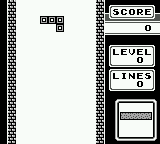

In [7]:
sample_image = dataset[0]["image"]
sample_image

Convert image to grayscale:

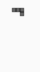

In [8]:
import torch
import multiprocessing
from torchvision.transforms.functional import to_tensor, to_pil_image, resize
from PIL import Image

def process_image_batch(images):
    # Preload config so we only access CONFIG once
    mode = CONFIG.get("image_mode", "color")
    scale = CONFIG.get("image_scale", 1.0)
    paddings = CONFIG.get("image_crop_paddings")
    noise_factor = CONFIG.get("noise_factor", 0.0)

    processed = []
    for image in images:
        # Convert mode
        if mode == "color":
            image = image.convert("RGB")
        elif mode == "grayscale":
            image = image.convert("L")
        elif mode == "black_and_white":
            image = image.convert("1")
        else:
            raise ValueError(f"Unsupported color mode: {mode}")

        # Crop if needed
        if paddings:
            padding = [int(x) for x in paddings.split(",")]
            width, height = image.size
            left = padding[3]
            top = padding[0]
            right = width - padding[1]
            bottom = height - padding[2]
            image = image.crop((left, top, right, bottom))

        # Convert to tensor
        image_ts = to_tensor(image)

        # Resize
        if scale != 1.0:
            _, h, w = image_ts.shape
            new_h, new_w = int(h * scale), int(w * scale)
            image_ts = resize(image_ts, [new_h, new_w])

        # Noise
        if noise_factor:
            noise = torch.randn_like(image_ts) * noise_factor
            image_ts = torch.clamp(image_ts + noise, 0.0, 1.0)

        image_ts = image_ts.to(torch.float16)
        processed.append(image_ts)

    return processed

processed_image_t = process_image_batch([sample_image])[0]
processed_image = to_pil_image(processed_image_t)
processed_image

Retrieve dataset image dimensions:

In [9]:
n_channels, image_height, image_width = processed_image_t.shape
n_channels, image_height, image_width

(1, 72, 40)

In [10]:
checksums = {}
def _filter(row):
    image = row["image"]
    checksum = image.tobytes()
    if checksum in checksums: return False
    checksums[checksum] = True
    return True

filtered_dataset = dataset.filter(
    _filter
)
filtered_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

Let's process dataset to ensure it has configured transformations (eg: grayscaling and image noise):

In [11]:
def _map_batch(batch):
    inputs = batch["image"]
    inputs = process_image_batch(inputs)
    targets = inputs
    return dict(
        input=inputs,
        target=targets
    )

processed_dataset = filtered_dataset.map(
    _map_batch,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Create frame collator that takes frame stacking into account:

In [12]:
from torch.utils.data import DataLoader

test_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step', 'action'])
test_dataset = test_dataset.with_format("torch")  # or "numpy" or "pandas"
#test_dataset = test_dataset.map(lambda x: x)  # forces full load

#list(test_dataset)
frame_skip = CONFIG['frame_skip']
mask = torch.arange(len(test_dataset)) % frame_skip == 0  # True for train
train_dataset = test_dataset.select(torch.nonzero(~mask).squeeze()).with_format("torch")
val_dataset = test_dataset.select(torch.nonzero(mask).squeeze()).with_format("torch")

In [13]:
train_dataset

Dataset({
    features: ['input', 'target'],
    num_rows: 3759
})

In [14]:
val_dataset

Dataset({
    features: ['input', 'target'],
    num_rows: 1253
})

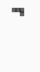

In [15]:
to_pil_image(val_dataset[0]["input"])

In [16]:
# In the DataLoader creation section:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(), # Or experiment with other values
    #persistent_workers=True, # Add this
    prefetch_factor=4 # Add this, experiment with values like 2, 4, 8
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count(), # Or experiment
    #persistent_workers=True, # Add this
    prefetch_factor=4 # Add this
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

In [17]:
from tsilva_notebook_utils.video import render_loader_video
render_loader_video(val_loader)

Rendering frames: 100%|██████████| 10/10 [00:01<00:00,  7.03it/s]


Create the model:

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None, use_fc=True):
        super(ConvAutoencoder, self).__init__()

        self.latent_noise_factor = CONFIG['latent_noise_factor']

        if latent_dim is None: latent_dim = CONFIG['latent_dim']
        self.use_fc = use_fc

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_fc:
            self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
            self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_fc:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_fc:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        # Add noise to latent space
        if self.training and self.latent_noise_factor > 0: # TODO: move to init
            noise = torch.randn_like(z) * self.latent_noise_factor
            z_noisy = z + noise
        else:
            z_noisy = z

        out = self.decode(z_noisy)
        return out, z

use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG["frame_stack_size"] * n_channels, n_channels, image_height, image_width, use_fc=use_fc)
model

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=5760, out_features=512, bias=True)
  (fc_dec): Linear(in_features=512, out_features=5760, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Create model, loss function and optimizer:

In [19]:
from tsilva_notebook_utils.torch import get_current_device

device = get_current_device()
use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG['frame_stack_size'] * n_channels, n_channels, image_height, image_width, use_fc=use_fc).to(device)
model = torch.compile(model)#, mode="max-autotune")

if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=n_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"], fused=True)

In [29]:

import numpy as np
from typing import Union, List, Optional, Any, Callable

def plot_embeddings_with_inputs(
    data: Union[np.ndarray, List[Any]],
    raw_inputs: List[Any],
    input_renderer: Optional[Callable[[Any], str]] = None,
    embedding_method: Union[str, Any] = "tsne",
    point_size: int = 5,
    plot_title: str = "2D Embedding Visualization",
    captions: Optional[List[str]] = None,
    random_state: int = 42,
    output_notebook=True,
    **embed_kwargs
):
    """
    Visualizes embeddings in 2D with hoverable input representations (images, text, tensors, etc.)

    Args:
        data: Feature vectors (or embeddings) to reduce to 2D.
        raw_inputs: Original inputs (images, tensors, strings, etc.).
        input_renderer: Function to convert an input into an HTML string (e.g., image, preview text).
        embedding_method: Embedding reducer - 'tsne', 'umap', 'pca', or custom.
        point_size: Size of scatter points.
        plot_title: Plot title.
        captions: Optional text labels.
        random_state: Random seed.
        **embed_kwargs: Passed to the embedding transformer.
    """
    from bokeh.plotting import figure, show
    from bokeh.models import ColumnDataSource, HoverTool
    from sklearn.manifold import TSNE

    if output_notebook:
        from bokeh.io import output_notebook
        output_notebook()

    if raw_inputs is None or len(raw_inputs) == 0:
        raise ValueError("raw_inputs must be non-empty.")
    if data is None or (isinstance(data, np.ndarray) and data.size == 0):
        raise ValueError("data must be a non-empty array or list.")
    if captions and len(captions) != len(raw_inputs):
        raise ValueError("captions must match raw_inputs in length.")

    # --- Compute Embedding ---
    if isinstance(embedding_method, str):
        embedding_method = embedding_method.lower()
        if embedding_method == "tsne":
            from sklearn.manifold import TSNE
            embedder = TSNE(n_components=2, random_state=random_state, **embed_kwargs)
        elif embedding_method == "umap":
            import umap
            embedder = umap.UMAP(n_components=2, random_state=random_state, **embed_kwargs)
        elif embedding_method == "pca":
            from sklearn.decomposition import PCA
            embedder = PCA(n_components=2, **embed_kwargs)
        else:
            raise ValueError(f"Unsupported method: {embedding_method}")
        embedding_2d = embedder.fit_transform(data)
    else:
        embedding_2d = embedding_method.fit_transform(data)

    # --- Input Renderer ---
    def default_renderer(inp):
        from PIL.Image import Image
        from io import BytesIO
        import base64
        if isinstance(inp, Image):
            buf = BytesIO(); inp.save(buf, format="PNG")
            b64 = base64.b64encode(buf.getvalue()).decode()
            return f"<img src='data:image/png;base64,{b64}' width='64' height='64'>"
        elif isinstance(inp, (str, int, float)):
            return f"<pre>{str(inp)}</pre>"
        elif isinstance(inp, np.ndarray):
            return f"<pre>{np.array2string(inp, precision=2, threshold=5)}</pre>"
        else:
            return f"<pre>{str(inp)}</pre>"

    render_func = input_renderer or default_renderer

    # --- Create Data Source ---
    source = ColumnDataSource(data=dict(
        x=embedding_2d[:, 0],
        y=embedding_2d[:, 1],
        preview=[render_func(inp) for inp in raw_inputs],
        label=captions or ["" for _ in raw_inputs],
    ))

    hover = HoverTool(tooltips="""
        <div>
            <div><strong>Coords:</strong> ($x{0.2f}, $y{0.2f})</div>
            <div>@preview{safe}</div>
            <div><strong>@label</strong></div>
        </div>
    """, formatters={'$x': 'printf', '$y': 'printf'})

    p = figure(title=plot_title, tools=[hover, "pan", "wheel_zoom", "box_zoom", "reset", "save"],
               width=800, height=600, x_axis_label="Dim 1", y_axis_label="Dim 2")
    p.scatter('x', 'y', source=source, size=point_size, fill_color="navy", alpha=0.6)

    if output_notebook: show(p)
    else: return p


Test a forward pass through the model to make sure shapes are accurate:

In [30]:
#from tsilva_notebook_utils.plots import plot_embeddings_with_inputs

z_list = []
frame_list = []

# Limit iterations (optional, remove if you want full dataset)
iters = 15 # Process slightly more than total data for dummy example
count = 0
total_samples_processed = 0
print("Starting data generation loop...")
for batch in train_loader:
    x = batch.get("input")
    y = batch.get("target")

    x = x.to(device)
    # y = y.to(device) # Target 'y' not needed unless calculating loss here

    with torch.no_grad():
        # Assume model returns (reconstruction, latent_vector)
        y_pred, z = model(x)

    # Append latent vectors and *original input frames* to lists (on CPU)
    z_list.append(z.detach().cpu())
    frame_list.extend(x.detach().cpu().unbind(0)) # Store the input 'x' corresponding to 'z'
    total_samples_processed += x.shape[0]

    count += 1
    if iters is not None and count >= iters:
        print(f"Reached limit of {iters} iterations. Breaking loop.")
        break

frames = [to_pil_image(x) for x in frame_list]
z_all = torch.cat(z_list, dim=0)      # Shape e.g., [N, latent_dim]
z_latent_np = z_all.numpy() # z_all should already be on CPU from loop
plot_embeddings_with_inputs(z_latent_np, frames)

Starting data generation loop...
Reached limit of 15 iterations. Breaking loop.


In [39]:
def log_heatmap(data, title, wandb_key):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(min(20, data.shape[1] * 0.4), 2.5))  # wider layout for long vectors
    im = ax.imshow(data, cmap='viridis', aspect='auto')

    # Annotate each cell
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', color='white', fontsize=7)

    # Ticks
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks([])  # optional: hide y-axis if it's just 1 row

    ax.set_title(title)
    fig.tight_layout()
    wandb.log({wandb_key: wandb.Image(fig)})
    plt.close(fig)

Run training:

In [42]:
import wandb
from tqdm import tqdm
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tsilva_notebook_utils.torch import calc_model_grad_norms

# Iterate over batches
from torch import autocast, GradScaler

import os
import wandb
from tqdm import tqdm
import torch
from torch import autocast
from torch.amp import GradScaler
from torch.nn.utils import clip_grad_norm_

def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID")
    assert NOTEBOOK_ID is not None, "NOTEBOOK_ID environment variable is not set"

    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        n_epochs = n_epochs or CONFIG['n_epochs']
        learning_rate = learning_rate or CONFIG['learning_rate']
        max_grad_norm = max_grad_norm or CONFIG['max_grad_norm']
        warmup_ratio = warmup_ratio or CONFIG['warmup_ratio']

        device = next(model.parameters()).device
        scaler = GradScaler('cuda')
        wandb.watch(model, log="all")

        total_steps = n_epochs * len(train_loader)
        warmup_steps = int(warmup_ratio * total_steps)

        def lr_lambda(step):
            return float(step) / float(max(1, warmup_steps)) if step < warmup_steps else 1.0

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

        global_step = 0
        latent_epsilon = 1e-6

        with tqdm(range(n_epochs), desc="Training") as pbar:
            for epoch in pbar:
                model.train()
                losses, all_zs = [], []

                for batch in train_loader:
                    x_batch = batch["input"].to(device)
                    y_batch = batch["target"].to(device)

                    optimizer.zero_grad()
                    global_step += 1

                    with autocast('cuda'):
                        logits, z = model(x_batch)
                        all_zs.append(z.detach().cpu())

                        reconstruction_loss = loss_fn(logits, y_batch)
                        sparsity_loss = CONFIG['sparsity_loss_alpha'] * torch.mean(torch.abs(z)) if CONFIG['sparsity_loss_alpha'] > 0 else 0
                        loss = reconstruction_loss + sparsity_loss

                        losses.append(loss.item())

                    scaler.scale(loss).backward()

                    if max_grad_norm:
                        scaler.unscale_(optimizer)
                        clip_grad_norm_(model.parameters(), max_grad_norm)

                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()

                model.eval()
                val_loss = None
                if epoch % CONFIG['validation_epochs'] == 0:
                    val_losses = []
                    for batch in val_loader:
                        x_batch = batch["input"].to(device)
                        y_batch = batch["target"].to(device)
                        with torch.no_grad():
                            logits, z = model(x_batch)
                            val_losses.append(loss_fn(logits, y_batch).item())
                    val_loss = sum(val_losses) / len(val_losses)

                #z_all = torch.cat(all_zs, dim=0).view(-1)
                z_all = torch.cat(all_zs, dim=0)  # shape: [total_samples, latent_dim]

                activation_rate = (z_all.abs() > latent_epsilon).float().mean(dim=0)


                wandb_stats = {
                    'meta/epoch': epoch + 1,
                    'meta/step': global_step,
                    'meta/learning_rate': scheduler.get_last_lr()[0],
                    'train/loss': sum(losses) / len(losses),
                    'train/reconstruction_loss': reconstruction_loss.item(),
                    'train/sparsity_loss': sparsity_loss.item() if CONFIG['sparsity_loss_alpha'] > 0 else 0,
                    'latent_z/sparsity': (z_all.abs() < latent_epsilon).float().mean().item(),
                    'latent_z/active_ratio': (z_all.abs() > latent_epsilon).float().mean().item(),
                    'latent_z/min': z_all.min().item(),
                    'latent_z/max': z_all.max().item(),
                    'latent_z/mean': z_all.mean().item(),
                    'latent_z/std': z_all.std().item(),
                    'latent_z/l2_norm': z_all.norm(p=2).item(),
                    'latent_z/l1_norm': z_all.norm(p=1).item(),
                    'latent_z/hist': wandb.Histogram(z_all.numpy()),
                    'latent_z/activation_per_dim': wandb.Histogram(activation_rate.cpu().numpy())
                }

                # all_zs is a list of tensors with shape [batch_size, latent_dim]
                # Stack them so shape is [num_batches, batch_size, latent_dim]
                #z_batched = torch.stack(all_zs)  # shape: [num_batches, batch_size, latent_dim]

                # Compute batch-level mean and median of z
                #batch_means = z_batched.mean(dim=1)   # shape: [num_batches, latent_dim]
                #batch_medians = z_batched.median(dim=1).values  # shape: [num_batches, latent_dim]

                # Now average across batches to get final [1, latent_dim]
                #mean_z = batch_means.mean(dim=0, keepdim=True).cpu().numpy()
                #median_z = batch_medians.median(dim=0).values.unsqueeze(0).cpu().numpy()

                #log_heatmap(mean_z, "Mean of z across batch", "latent_z/mean_heatmap")
                #log_heatmap(median_z, "Median of z across batch", "latent_z/median_heatmap")


                pbar_stats = {
                    'epoch': epoch + 1,
                    'train_loss': f'{wandb_stats["train/loss"]:.4f}',
                    'lr': f'{wandb_stats["meta/learning_rate"]:.6e}'
                }

                if eval_fn:
                    eval_results = eval_fn()
                    wandb_stats['val/loss'] = eval_results['loss']
                    wandb_stats['val/accuracy'] = eval_results['accuracy']
                    pbar_stats['val_acc'] = f'{eval_results["accuracy"] * 100:.2f}%'

                wandb.log(wandb_stats, step=global_step)
                pbar.set_postfix(pbar_stats)

        return run

train(model, loss_fn, optimizer, train_loader)

Training:  45%|████▍     | 447/1000 [20:41<24:37,  2.67s/it, epoch=447, train_loss=0.0019, lr=1.000000e-03]Exception in thread Thread-694 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/multiprocessing/reductions.py", line 541, in rebuild

latent_z/active_ratio,▃▃▄▄▇█▆▅▆▆▆▆▅▅▆▃▄▇█▅▆▃▇▄▅▆▁▂▂▅▄▅▆▅▅▃▅▄▆▄
latent_z/l1_norm,█▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
latent_z/l2_norm,▇█▇█▇▇▆▅▅▅▄▄▅▅▅▅▄▄▃▄▄▃▃▃▄▃▂▃▂▃▃▂▂▃▁▂▂▂▂▂
latent_z/max,▁▁▂▃▄▁▄▆▃▅▆▄▇▆▅▇█▆▇▆▅▅▆▇▅▆▆▄▆▇▆▇█▇▆▆▅▆▅▆
latent_z/mean,▂▁▁▂▃▃▃▄▂▃▃▃▄▃▄▄▅▅▅▄▅▆▆▆▆▅▆▇▇▇▇▇▇█▇█████
latent_z/min,▂▃▁▂▂▁▂▃▂▂▂▃▂▂▃▃▃▂▅▄▅▃▅▄▆▆▅▆▅▆▇▆█▇▆▆████
latent_z/sparsity,█▅▃▅▁▄▃▇▆▂▆▅▇▆▅▄▅▂▇█▇█▆▅▅▅▅▆█▄▆▅▄▄▅▄▄▆▇▂
latent_z/std,▇█▇▇▇▇▇▇▅▆▆▅▅▅▅▅▅▄▅▅▃▅▄▃▄▃▃▃▃▃▃▃▂▂▁▂▁▁▁▁
meta/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
meta/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meta/step,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇████


KeyboardInterrupt: 

In [69]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latents = []
for batch in test_loader:
  x_batch = batch["input"].to(device)
  with torch.no_grad():
    z = model.encode(x_batch)
    latents.append(z.detach().cpu())
latents = torch.cat(latents)
n_samples = latents.shape[0]
print(latents.shape)
mean = latents.mean(dim=0)
cov = torch.cov(latents.T)  # Note: PyTorch 2.0+ has torch.cov

# Sampling from multivariate normal in PyTorch:
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
samples = mvn.sample((1000,)).to(device)
with torch.no_grad(): decoded = model.decode(samples)
frames_t = decoded.unbind(0)

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    save_frames_to_dir(frames_t, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

torch.Size([5012, 512])


torch.Size([5012, 512])

In [74]:
from sklearn.decomposition import PCA

latents_np = latents.numpy()
latent_dim = CONFIG['latent_dim']
pca = PCA(n_components=latent_dim)
latents_pca = pca.fit_transform(latents_np)

# Sample along the top 2 PCA directions
t = torch.linspace(-3, 3, steps=100)
samples_pca = []
for i in range(len(t)):
    point = torch.tensor(pca.mean_) + t[i] * torch.tensor(pca.components_[0])
    samples_pca.append(point)
samples = torch.stack(samples_pca).to(device)

with torch.no_grad(): decoded = model.decode(samples)
frames_t = decoded.unbind(0)

with tempfile.TemporaryDirectory() as temp_dir:
    save_frames_to_dir(frames_t, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

Saving frames: 100%|██████████| 100/100 [00:00<00:00, 1994.89it/s]


In [60]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(latent_dim):
        encoded = torch.zeros(latent_dim, device=device)
        encoded[i] = 1.0
        encoded = encoded.unsqueeze(0)  # shape: (1, latent_dim)
        decoded = model.decode(encoded)
        frames.append(decoded.squeeze())
    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)
video

Saving frames: 100%|██████████| 512/512 [00:00<00:00, 3541.93it/s]


In [59]:
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir
import torch.nn.functional as F
import random

latent_dim = CONFIG['latent_dim']
sparsity_ratio = 0.05  # Match your model's average sparsity
num_frames = latent_dim  # or choose more/less depending on what you want to visualize

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for _ in range(num_frames):
        # Start with all zeros
        encoded = torch.zeros(latent_dim, device=device)

        # Randomly activate a sparse subset
        n_active = int(latent_dim * sparsity_ratio)
        active_indices = random.sample(range(latent_dim), n_active)

        # Assign random values (or fixed if you want consistency)
        encoded[active_indices] = torch.rand(n_active, device=device)

        # Decode and save frame
        decoded = model.decode(encoded.unsqueeze(0))
        frame = decoded.squeeze().detach().cpu()
        frames.append(frame)

    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10, scale=2)

video

Saving frames: 100%|██████████| 512/512 [00:00<00:00, 4642.33it/s]


Render video of autoencoder predictions:

In [75]:
from tsilva_notebook_utils.video import render_autoencoder_video
render_autoencoder_video(model, val_loader, fps=10, scale=2)

TypeError: render_autoencoder_video() got an unexpected keyword argument 'scale'

⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()